<a href="https://colab.research.google.com/github/soumilimahindar-Asure/Machine-Learning/blob/main/AIML_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== FIRST 5 ROWS ==========
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

========== DATASET SHAPE ==========
(768, 9)

========== COLUMN NAMES ==========
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

========== DATASET INFO

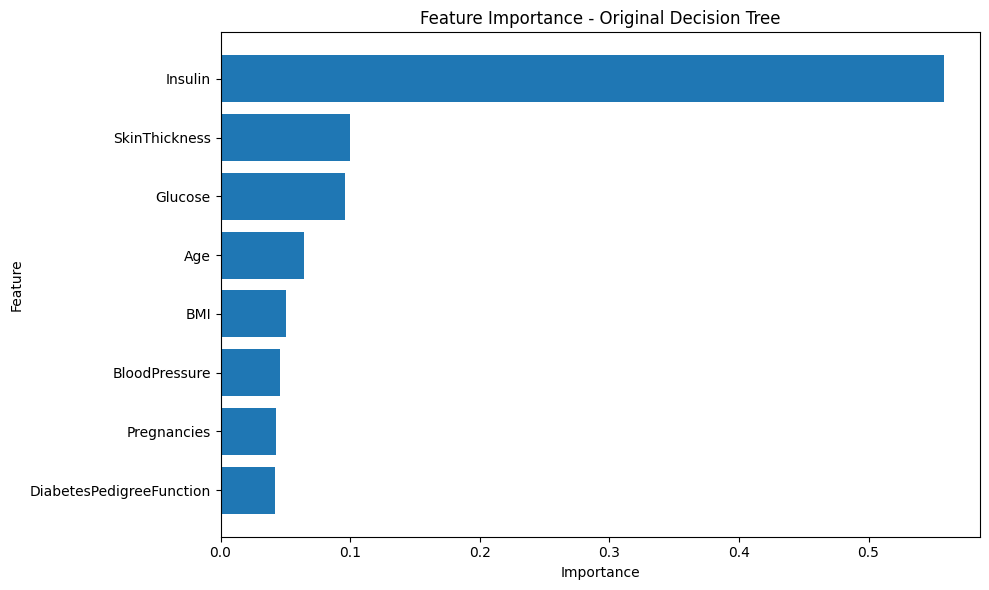

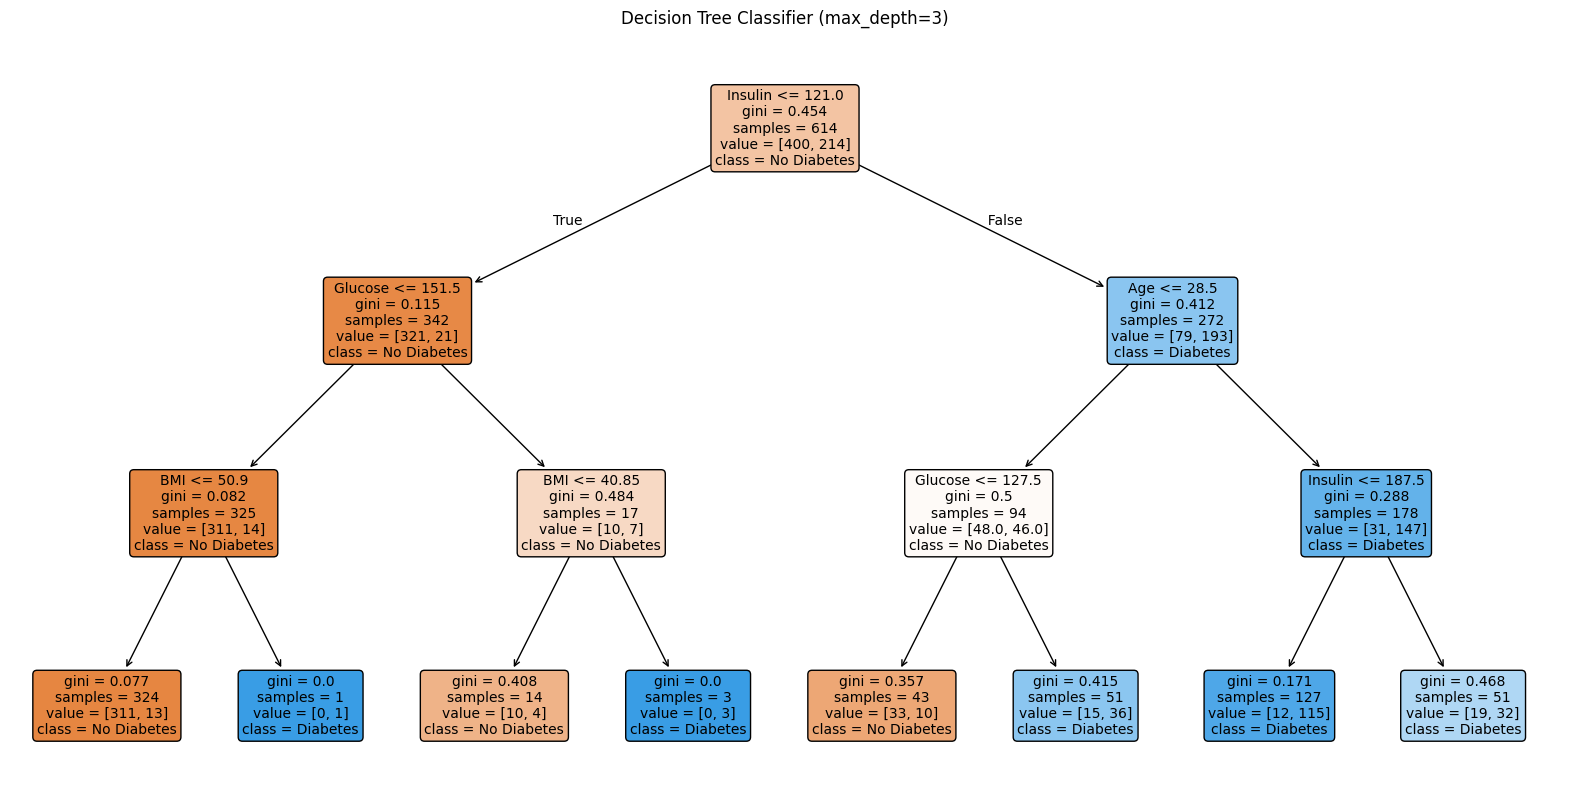



                  FINAL SUMMARY

Original Decision Tree:
Accuracy  : 0.8117
Precision : 0.7451
Recall    : 0.7037
F1-Score  : 0.7238

Decision Tree (max_depth=3):
Accuracy  : 0.8506
Precision : 0.7627
Recall    : 0.8333
F1-Score  : 0.7965

Better model based on F1-Score:
Decision Tree with max_depth=3


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
df = pd.read_csv("Pima Indians Diabetes Dataset.csv")

print("\n FIRST 5 ROWS ")
print(df.head())
print("\n DATASET SHAPE")
print(df.shape)
print("\n COLUMN NAMES ")
print(df.columns)
print("\n DATASET INFORMATION ")
print(df.info())
print("\n FINAL COLUMN NAMES ")
print(df.columns.tolist())
df.columns = df.columns.str.strip()
print("\n CLEANED COLUMN NAMES ")
print(df.columns.tolist())
print("\n MISSING VALUES ")
print(df.isnull().sum())
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
print("\n ZERO VALUES ")
for column in zero_columns:

    if column in df.columns:
        zero_count = (df[column] == 0).sum()
        print(column, ":", zero_count)
for column in zero_columns:

    if column in df.columns:
        df[column] = df[column].replace(0, np.nan)
print("\n MISSING VALUES AFTER ZERO REPLACEMENT ")
print(df.isnull().sum())
for column in zero_columns:

    if column in df.columns:
        df[column] = df[column].fillna(df[column].median())
print("\n MISSING VALUES AFTER MEDIAN IMPUTATION ")
print(df.isnull().sum())
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
print("\n FEATURES (X) ")
print(X.columns.tolist())
print("\n TARGET (y)")
print(y.name)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("\n DATA SPLIT ")
print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

conf_matrix = confusion_matrix(
    y_test,
    y_pred
)


print("\n")
print("=" * 60)
print("       ORIGINAL DECISION TREE RESULTS")
print("=" * 60)

print("\nAccuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)
dt_model_depth3 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)
dt_model_depth3.fit(
    X_train,
    y_train
)
y_pred_depth3 = dt_model_depth3.predict(X_test)
accuracy_depth3 = accuracy_score(
    y_test,
    y_pred_depth3
)

precision_depth3 = precision_score(
    y_test,
    y_pred_depth3,
    zero_division=0
)

recall_depth3 = recall_score(
    y_test,
    y_pred_depth3,
    zero_division=0
)

f1_depth3 = f1_score(
    y_test,
    y_pred_depth3,
    zero_division=0
)

conf_matrix_depth3 = confusion_matrix(
    y_test,
    y_pred_depth3
)


print("\n")
print("=" * 60)
print("       DECISION TREE max_depth=3 RESULTS")
print("=" * 60)

print("\nAccuracy  :", round(accuracy_depth3, 4))
print("Precision :", round(precision_depth3, 4))
print("Recall    :", round(recall_depth3, 4))
print("F1-Score  :", round(f1_depth3, 4))

print("\nConfusion Matrix:")
print(conf_matrix_depth3)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_depth3,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Original Decision Tree": [
        accuracy,
        precision,
        recall,
        f1
    ],

    "Decision Tree (max_depth=3)": [
        accuracy_depth3,
        precision_depth3,
        recall_depth3,
        f1_depth3
    ]
})


print("\n")
print("=" * 60)
print("             MODEL COMPARISON")
print("=" * 60)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": dt_model.feature_importances_

})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print("\n")
print("=" * 60)
print("       FEATURE IMPORTANCE - ORIGINAL TREE")
print("=" * 60)

print(
    feature_importance.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)
feature_importance_depth3 = pd.DataFrame({

    "Feature": X.columns,

    "Importance": dt_model_depth3.feature_importances_

})
feature_importance_depth3 = feature_importance_depth3.sort_values(
    by="Importance",
    ascending=False
)

print("\n")
print("=" * 60)
print("       FEATURE IMPORTANCE - max_depth=3")
print("=" * 60)

print(
    feature_importance_depth3.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Feature Importance - Original Decision Tree"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model_depth3,

    feature_names=X.columns,

    class_names=[
        "No Diabetes",
        "Diabetes"
    ],

    filled=True,

    rounded=True,

    fontsize=10
)

plt.title(
    "Decision Tree Classifier (max_depth=3)"
)
plt.show()
print("\n")
print("=" * 60)
print("                  FINAL SUMMARY")
print("=" * 60)

print("\nOriginal Decision Tree:")
print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))

print("\nDecision Tree (max_depth=3):")
print("Accuracy  :", round(accuracy_depth3, 4))
print("Precision :", round(precision_depth3, 4))
print("Recall    :", round(recall_depth3, 4))
print("F1-Score  :", round(f1_depth3, 4))
if f1 > f1_depth3:

    print("\nBetter model based on F1-Score:")
    print("Original Decision Tree")

elif f1_depth3 > f1:

    print("\nBetter model based on F1-Score:")
    print("Decision Tree with max_depth=3")

else:

    print("\nBoth models have the same F1-Score.")